# Constructing an *unseen-awg* weather generator

- multiple ways to set up for reanalysis or reforecast datasets. 
- We implemented for ERA5 & [IFS reforecasts] neöpw

```bash
snakemake --configfile configs/weather_generators/reforecasts_no_bias_correction.yaml
```

## Using Snakemake to Configure Generation

We employ [snakemake](https://snakemake.readthedocs.io/en/stable/) to automatically execute and schedule all required steps of the preprocessing. You can run `snakemake` in the terminal using
```bash
conda activate unseen-awg  # activate conda environment
cd <project base directory>  # navigate to unseen-awg base directory
snakemake --cores 1  --dry-run  --configfile configs/weather_generators/<selected weather generator>.yaml  # execute snakemake
```

With the `--dry-run` flag, `snakemake` performs a test without actually executing all required scripts, `--configfile configs/weather_generators/<selected weather generator>.yaml` appends the configuration of a weather generator to the task (this is necessary for the script to work).

By default, `snakemake` executes a test setup for the weather generator. It builds a weather generator, tunes it, and creates a combined dataset for the impact variables.

Adapt the `Snakefile` to produce different outputs and adapt the workflow to your task and system.

## Preprocessing Details and Motivation

### Reforecast Data

In [33]:
import os

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml


In [34]:
single_forecast = xr.open_dataset
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

path_single_cf = os.path.join(
    paths["dir_ReforecastsRaw"], "circulation/cf/2023-06-29.grib"
)
path_single_pf = os.path.join(
    paths["dir_ReforecastsRaw"], "circulation/pf/2023-06-29.grib"
)

path_combined = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_circulation_reforecasts/combined_5e06172f.zarr",
)

path_restructured = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_circulation_reforecasts/restructured_5e06172f_f40e9460.nc",
)

path_dayofyear_year = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_circulation_reforecasts/data_year_dayofyear_5e06172f_f40e9460.zarr",
)

path_era5 = os.path.join(
    paths["dir_ERA5Raw"],
    "/data/compoundx/datasets/ERA5_daily/2m_temperature_daily_mean/2010.nc",
)

"""
path_era5_combined = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_circulation_era5/<insert>.zarr",
)
"""

'\npath_era5_combined = os.path.join(\n    paths["dir_preprocessed_datasets"],\n    "preprocessed_circulation_era5/<insert>.zarr",\n)\n'

In [35]:
# load control and perturbed forecast and combine them:
cf = xr.open_dataset(path_single_cf).expand_dims("number")
pf = xr.open_dataset(path_single_pf)

xr.combine_by_coords([cf, pf], combine_attrs="drop_conflicts").drop_attrs()

<xarray.Dataset> Size: 8GB
Dimensions:        (number: 11, time: 20, step: 185, latitude: 151,
                    longitude: 326)
Coordinates:
  * number         (number) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * time           (time) datetime64[ns] 160B 2003-06-29 ... 2022-06-29
  * step           (step) timedelta64[ns] 1kB 0 days 00:00:00 ... 46 days 00:...
  * latitude       (latitude) float64 1kB 80.0 79.6 79.2 78.8 ... 20.8 20.4 20.0
  * longitude      (longitude) float64 3kB -90.0 -89.6 -89.2 ... 39.2 39.6 40.0
    isobaricInhPa  float64 8B 500.0
    valid_time     (time, step) datetime64[ns] 30kB 2003-06-29 ... 2022-08-14
Data variables:
    z              (number, time, step, latitude, longitude) float32 8GB 5.43...

In [36]:
ds_combined = xr.open_zarr(path_combined)
ds_combined.drop_attrs()

<xarray.Dataset> Size: 9GB
Dimensions:              (ensemble_member: 11, init_time: 2560, lead_time: 46,
                          latitude: 18, longitude: 49)
Coordinates:
  * ensemble_member      (ensemble_member) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * init_time            (init_time) datetime64[ns] 20kB 2003-06-29 ... 2023-...
  * lead_time            (lead_time) timedelta64[ns] 368B 0 days ... 45 days
  * latitude             (latitude) float64 144B 30.0 32.5 35.0 ... 70.0 72.5
  * longitude            (longitude) float64 392B -80.0 -77.5 ... 37.5 40.0
    isobaricInhPa        float64 8B ...
Data variables:
    geopotential_height  (ensemble_member, init_time, lead_time, latitude, longitude) float64 9GB dask.array<chunksize=(10, 1, 46, 18, 49), meta=np.ndarray>

- What is relevant when computing similarities is the valid_time and whether the day of year of the valid time of two states are similar, therefore one would like to organize the dataset by valid_time, e.g. by using dimensions (valid_time, lead_time) instead of (init_time, lead_time). Like this computations could easily be vectorized.
- However: forecasts aren't started every single day. Therefore, there would be a lot of unregularly distributed empty spots in the resulting dataset, here's an example for a range of dates:

In [37]:
ds_combined = ds_combined.assign_coords(
    valid_time=ds_combined.init_time + ds_combined.lead_time
)
unique_valid_times = np.unique(ds_combined.valid_time)

vt_min = np.datetime64("2010-01-01", "ns")
vt_max = np.datetime64("2010-02-01", "ns")

range_vt = np.arange(vt_min, vt_max, np.timedelta64(1, "D"))

In [38]:
contains_data = xr.DataArray(
    np.full((len(ds_combined.lead_time), len(range_vt)), fill_value=False, dtype=bool),
    coords={"lead_time": ds_combined.lead_time, "valid_time": range_vt},
)

for lt in ds_combined.lead_time:
    for j, vt in enumerate(range_vt):
        contains_data.loc[{"lead_time": lt, "valid_time": vt}] = np.isin(
            vt, ds_combined.valid_time.sel(lead_time=lt)
        )
contains_data = contains_data.assign_coords(
    lead_time=contains_data.lead_time / np.timedelta64(1, "D")
)
contains_data.drop_attrs()

<xarray.DataArray (lead_time: 46, valid_time: 31)> Size: 1kB
array([[ True, False, False, ...,  True, False, False],
       [False,  True, False, ..., False,  True, False],
       [False, False,  True, ..., False, False,  True],
       ...,
       [False,  True, False, ..., False,  True, False],
       [False, False,  True, ..., False, False,  True],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * lead_time   (lead_time) float64 368B 0.0 1.0 2.0 3.0 ... 42.0 43.0 44.0 45.0
  * valid_time  (valid_time) datetime64[ns] 248B 2010-01-01 ... 2010-01-31

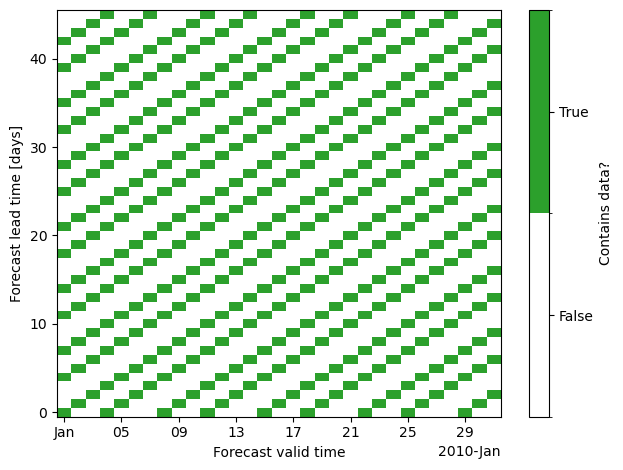

In [39]:
# Create a discrete colormap for binary data
cmap = mcolors.ListedColormap(["#ffffff", "#2ca02c"])  # Red=False, Green=True
bounds = [0, 0.5, 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots()
im = contains_data.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Contains data?",
        "ticks": [0.25, 0.75],
    },
)

cbar = im.colorbar
cbar.ax.set_yticklabels(["False", "True"])

plt.xlabel("Forecast valid time")
plt.ylabel("Forecast lead time [days]")
plt.tight_layout()
plt.show()


- Instead: use valid_time and introduce a new dimension "sample" which we populate with all forecasts for the same lead_time. Use a look-up table to extract lead_time / init_time from valid_time and sample

In [40]:
ds_restructured = xr.open_dataset(path_restructured)
ds_restructured.drop_attrs()

<xarray.Dataset> Size: 16GB
Dimensions:              (valid_time: 7430, sample: 27, ensemble_member: 11,
                          lag: 1, latitude: 18, longitude: 49)
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 59kB 2003-06-29 ... 2023...
  * sample               (sample) int64 216B 0 1 2 3 4 5 6 ... 21 22 23 24 25 26
  * ensemble_member      (ensemble_member) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * lag                  (lag) timedelta64[ns] 8B 00:00:00
  * latitude             (latitude) float64 144B 30.0 32.5 35.0 ... 70.0 72.5
  * longitude            (longitude) float64 392B -80.0 -77.5 ... 37.5 40.0
    isobaricInhPa        float64 8B ...
Data variables:
    geopotential_height  (valid_time, sample, ensemble_member, lag, latitude, longitude) float64 16GB ...
    init_time            (valid_time, sample) datetime64[ns] 2MB ...

Repeating the plot above with the new dataset and dimensions (valid_time, sample), we see that we can avoid a lot of data.

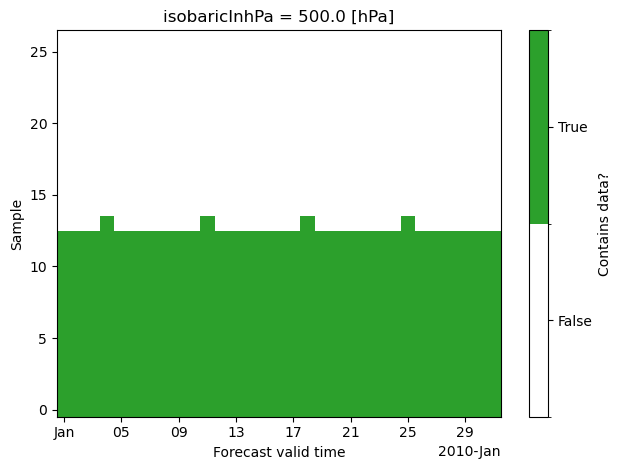

In [41]:
# Create a discrete colormap for binary data
cmap = mcolors.ListedColormap(["#ffffff", "#2ca02c"])  # Red=False, Green=True
bounds = [0, 0.5, 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots()
im = (
    (~np.isnat(ds_restructured.init_time.sel(valid_time=range_vt)))
    .transpose()
    .plot(
        ax=ax,
        cmap=cmap,
        norm=norm,
        add_colorbar=True,
        cbar_kwargs={
            "label": "Contains data?",
            "ticks": [0.25, 0.75],
        },
    )
)


cbar = im.colorbar
cbar.ax.set_yticklabels(["False", "True"])

plt.xlabel("Forecast valid time")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()


In [42]:
ds_combined.lead_time

<xarray.DataArray 'lead_time' (lead_time: 46)> Size: 368B
array([               0,   86400000000000,  172800000000000,  259200000000000,
        345600000000000,  432000000000000,  518400000000000,  604800000000000,
        691200000000000,  777600000000000,  864000000000000,  950400000000000,
       1036800000000000, 1123200000000000, 1209600000000000, 1296000000000000,
       1382400000000000, 1468800000000000, 1555200000000000, 1641600000000000,
       1728000000000000, 1814400000000000, 1900800000000000, 1987200000000000,
       2073600000000000, 2160000000000000, 2246400000000000, 2332800000000000,
       2419200000000000, 2505600000000000, 2592000000000000, 2678400000000000,
       2764800000000000, 2851200000000000, 2937600000000000, 3024000000000000,
       3110400000000000, 3196800000000000, 3283200000000000, 3369600000000000,
       3456000000000000, 3542400000000000, 3628800000000000, 3715200000000000,
       3801600000000000, 3888000000000000], dtype='timedelta64[ns]')
Coordinates:
  * lead_time      (lead_time) timedelta64[ns] 368B 0 days 1 days ... 45 days
    isobaricInhPa  float64 8B 500.0

The size of the `sample` dimension is chosen as the maximum states with same `valid_time`. This is already smaller than the lead_time dimension:

In [43]:
print("Length lead_time dimension:", len(ds_combined.lead_time))
print("Length sample dimension:", len(ds_restructured.sample))

Length lead_time dimension: 46
Length sample dimension: 27


In our dataset, everything above `sample == 13` contains almost exclusively missing data, so that for weather generators, we usually restrict the data to samples `0` to `13` by setting the `n_samples: 14` in the corresponding configuration file.

Extra preprocessing step:
- split valid_time dimension into year and dayofyear dimensions. What we care about is that calendar dates are similar, therefore working with dayofyear is useful
- chunk along dayofyear dimension, so that only some of the chunks need to be loaded during the computation and memory is used efficiently.

In [44]:
xr.open_zarr(path_dayofyear_year)["geopotential_height"].drop_attrs()

<xarray.DataArray 'geopotential_height' (dayofyear: 366, year: 21, sample: 27,
                                         ensemble_member: 11, lag: 1,
                                         latitude: 18, longitude: 49)> Size: 16GB
dask.array<open_dataset-geopotential_height, shape=(366, 21, 27, 11, 1, 18, 49), dtype=float64, chunksize=(1, 21, 27, 11, 1, 18, 49), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear        (dayofyear) int64 3kB 1 2 3 4 5 6 ... 362 363 364 365 366
  * year             (year) int64 168B 2003 2004 2005 2006 ... 2021 2022 2023
  * sample           (sample) int64 216B 0 1 2 3 4 5 6 ... 20 21 22 23 24 25 26
  * ensemble_member  (ensemble_member) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * lag              (lag) timedelta64[ns] 8B 00:00:00
  * latitude         (latitude) float64 144B 30.0 32.5 35.0 ... 67.5 70.0 72.5
  * longitude        (longitude) float64 392B -80.0 -77.5 -75.0 ... 37.5 40.0

### ERA5 Data

- Implemented weather generator that works with daily aggregated ERA5 data
- Stored as 1 file per year per variable in a separate directory for each variable

In [45]:
xr.open_dataarray(path_era5).drop_attrs()

<xarray.DataArray 't2m' (valid_time: 365, latitude: 721, longitude: 1440)> Size: 2GB
[378957600 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2010-01-01 ... 2010-12-31
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...

- Script `ds_from_era5.py` to convert this to the same "combined" zarr store format as the reforecasts:

In [46]:
# xr.open_zarr(path_era5_combined).drop_attrs()

Rest of processing follows what is done for reforecast data.